# CliffordClock end-to-end demo

This notebook walks the full pipeline by hand: synthesize a field, fit a
smoother, sample an ensemble, integrate the rotor path equation, and
analyze the result. This is the same composition `cliffordclock.pipeline.run_pipeline`
(and the `cliffordclock run` CLI) automate. Every equation cited (`E9`, `E11`, ...) refers to `docs/CONVENTIONS.md`.
This notebook narrates what each step computes; the derivations and the
underlying physics live in that document.

**Status: pre-validation research code.** The numbers this notebook
produces are a synthetic self-consistency demonstration of the
algorithm: the field, the ensemble, and the resulting shift are all
generated internally, with no comparison to a published or measured
value. Benchmarking against experimental data is a separate validation
class, described in the top-level README's Status section.

In [1]:
%matplotlib inline
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from cliffordclock.analytics import (
    build_report,
    coherence_function,
    line_profile,
)
from cliffordclock.constants import TAU_COMPTON
from cliffordclock.ensemble import EnsembleSampler, HarmonicTrap, get_species
from cliffordclock.ensemble.classical import propagate_verlet
from cliffordclock.fields import FieldSmoother
from cliffordclock.fields.synthetic import gaussian_bump_field, sample_on_grid
from cliffordclock.integrator.worldline import integrate_ensemble

np.set_printoptions(precision=4)

## 1. Synthesize and smooth a field (E11-E13)

We use a closed-form Gaussian-bump test field
(`cliffordclock.fields.synthetic.gaussian_bump_field`) as a stand-in for a
CAD/FEA-exported field grid. We sample it onto a regular grid and fit it with
the same `FieldSmoother` (E11 baseline + E12 thin-plate-spline
radial-basis-function, RBF, residual) that a real CSV import would use.
`grad_E` is exact autodiff of the fitted interpolant (E13), so `E` and `grad_E`
are consistent by construction.

In [2]:
e_fn, grad_fn = gaussian_bump_field(
    amplitude=jnp.array([10.0, 0.0, -5.0]), center=jnp.array([0.0, 0.0, 0.0]), width=2.0e-6
)
grid = sample_on_grid(e_fn, ((-5e-6, 5e-6), (-5e-6, 5e-6), (-5e-6, 5e-6)), n_per_axis=9)
smoother = FieldSmoother.fit(grid, method="auto", smoothing=0.0)
print(f"fit {grid.points.shape[0]} points; RBF method={smoother.method!r}")

fit 729 points; RBF method='rbf'


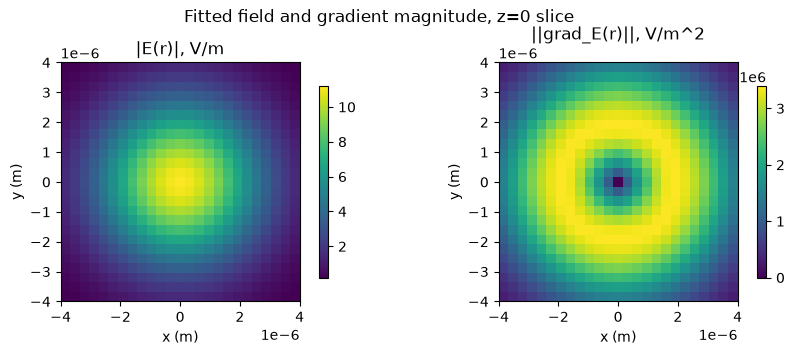

In [3]:
# Field + gradient magnitude on a z=0 slice, evaluated through the fitted smoother.
axis = np.linspace(-4e-6, 4e-6, 25)
xx, yy = np.meshgrid(axis, axis, indexing="ij")
pos_slice = jnp.asarray(np.stack([xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())], axis=-1))
e_slice, grad_e_slice = smoother.evaluate(pos_slice)
e_mag = np.asarray(jnp.linalg.norm(e_slice, axis=-1)).reshape(xx.shape)
grad_sq_sum = jnp.sum(grad_e_slice**2, axis=(-1, -2))
grad_frobenius = np.asarray(jnp.sqrt(grad_sq_sum)).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, data, title in zip(
    axes, [e_mag, grad_frobenius], ["|E(r)|, V/m", "||grad_E(r)||, V/m^2"], strict=True
):
    im = ax.imshow(data.T, origin="lower", extent=(axis[0], axis[-1], axis[0], axis[-1]))
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("Fitted field and gradient magnitude, z=0 slice")
fig.tight_layout()
plt.show()

## 2. Sample an ensemble

A classical Maxwell-Boltzmann ensemble in a harmonic trap, propagated with
velocity-Verlet. The trajectory step `dt` is derived from the *same* `dtau`
(Compton units, E9) the rotor integrator below uses. Trajectory samples
therefore land exactly `dtau` apart, the assumption the integrator's
finite-difference velocity depends on (see `cliffordclock.pipeline`'s module
docstring for the same binding rule the CLI enforces).

On that Compton-unit step the atoms are effectively frozen: 300 steps span
about 2e-19 s of lab time, the timescale separation `docs/timescales.md` is
built around. Those frozen trajectories are the right input for the phase
integral. They would plot as single points, though, so the figure below
propagates the same ensemble over two trap periods purely to make the thermal
orbits visible.

trajectories shape: (40, 301, 3)  (M, steps+1, 3)


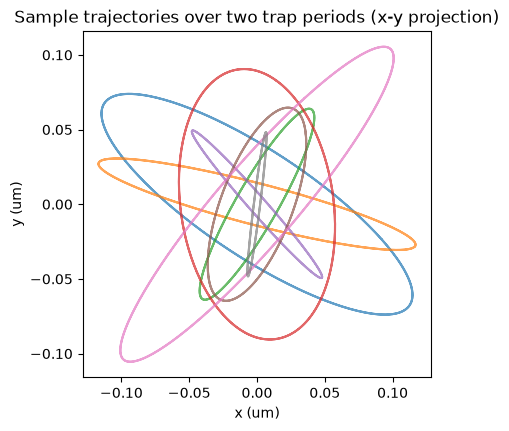

In [4]:
species = get_species("Sr87")
trap = HarmonicTrap(omega_xyz=(2.0e5, 2.0e5, 2.0e5))
sampler = EnsembleSampler(species=species, trap_type=trap, temperature_uK=1.0)

key = jax.random.PRNGKey(0)
positions, velocities = sampler.generate_classical_ensemble(key, num_particles=40)

dtau = 0.5  # Compton-unit step, E9
n_steps = 300
dt_seconds = dtau * TAU_COMPTON  # same dtau drives both trajectory sampling and the integrator
trajectories = propagate_verlet(trap, positions, velocities, dt_seconds, n_steps)
print(f"trajectories shape: {trajectories.shape}  (M, steps+1, 3)")

# Visualization only: the integration below still uses `trajectories`.
trap_period_s = 2.0 * np.pi / trap.omega_xyz[0]
viz_steps = 600
viz_dt_s = 2.0 * trap_period_s / viz_steps
viz_trajectories = propagate_verlet(trap, positions, velocities, viz_dt_s, viz_steps)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for i in range(min(8, viz_trajectories.shape[0])):
    traj_i = np.asarray(viz_trajectories[i])
    ax.plot(traj_i[:, 0] * 1e6, traj_i[:, 1] * 1e6, alpha=0.7)
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("Sample trajectories over two trap periods (x-y projection)")
plt.show()

## 3. Integrate the rotor path equation (E9, E14a, E17-E24)

`integrate_ensemble` advances the Cl(1,3) rotor, this project's
spacetime-algebra representation of the atom's internal clock, along every
worldline (`dR/dtau~ = -1/2 Omega R`, E17) and accumulates the perturbation
phase (E22). `mu` is an explicit effective dipole moment (E14a). See
`docs/CONVENTIONS.md` E14a/E14b for how a physically meaningful `mu` relates to
a differential polarizability; the value below is chosen only to produce an
O(1e-15) synthetic shift on this short demo run.

In [5]:
mu = jnp.array([1.0e-24, 0.0, 0.0])  # C.m, E14a -- synthetic demo value, see markdown above

ensemble_result = integrate_ensemble(smoother.evaluate, trajectories, dtau, mu)
print(f"phase dtype: {ensemble_result.phase.dtype}")
print(f"max rotor-norm drift (E20): {float(jnp.max(ensemble_result.max_norm_drift)):.3e}")
print(
    "max |rotor phase - scalar phase| (E24 cross-check): "
    f"{float(jnp.max(jnp.abs(ensemble_result.phase_rotor - ensemble_result.phase))):.3e}"
)

phase dtype: float64
max rotor-norm drift (E20): 0.000e+00
max |rotor phase - scalar phase| (E24 cross-check): 0.000e+00


## 4. Analyze and report (E21-E28)

`build_report` turns the per-atom accumulated phases into the mean
fractional shift (E23), its standard error, and the inhomogeneous
dephasing time T2* (E27); `coherence_function`/`line_profile` give the
spectral line shape (E26, E28).

In [6]:
t_interrogation_s = n_steps * dt_seconds
report = build_report(
    ensemble_result.phase,
    species,
    t_interrogation_s,
    ensemble_type="classical_monte_carlo",
    uncertainty_notes="Synthetic demo run; no systematic budget modeled.",
)
print(
    f"mean fractional shift: {report.mean_fractional_shift:+.3e} "
    f"+/- {report.shift_std_error:.2e} (SEM)"
)
print(f"T2*: {report.t2_star_s:.3e} s")
print(f"interrogation time: {report.interrogation_time_s:.3e} s")

mean fractional shift: +1.220e-10 +/- 2.21e-14 (SEM)
T2*: 1.305e-08 s
interrogation time: 1.932e-19 s


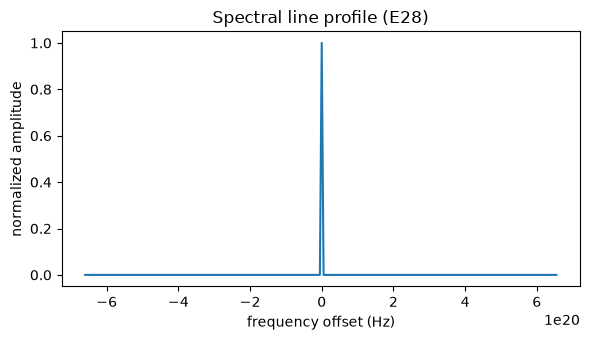

In [7]:
n_time = 256
dt_line_s = t_interrogation_s / (n_time - 1)
t_grid_s = np.arange(n_time) * dt_line_s
coherence = coherence_function(ensemble_result.phase, t_interrogation_s, t_grid_s)
freqs_hz, amplitude = line_profile(coherence, dt_line_s)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(freqs_hz, amplitude)
ax.set_xlabel("frequency offset (Hz)")
ax.set_ylabel("normalized amplitude")
ax.set_title("Spectral line profile (E28)")
fig.tight_layout()
plt.show()

## 5. The one-call equivalent: `run_pipeline`

Everything above is what `cliffordclock.pipeline.run_pipeline` (and the
`cliffordclock run` CLI) does from a declarative `config.yaml`. See
`docs/cli.md` for the schema and `examples/*.yaml` for runnable configs.

In [8]:
from pathlib import Path

from cliffordclock.pipeline import PipelineConfig, run_pipeline

example_config_path = Path("..") / "examples" / "quadrupole_classical.yaml"
config = PipelineConfig.from_yaml(example_config_path)
cli_equivalent_report = run_pipeline(config)
print(
    f"{example_config_path.name}: mean fractional shift = "
    f"{cli_equivalent_report.mean_fractional_shift:+.3e} "
    f"+/- {cli_equivalent_report.shift_std_error:.2e} (SEM)"
)

quadrupole_classical.yaml: mean fractional shift = +4.700e-14 +/- 4.85e-14 (SEM)


## Where to go next

- `docs/CONVENTIONS.md`: every equation cited above, with units and the
  sprint's resolved physics-interpretation decisions (section 11).
- `docs/cli.md`: the `cliffordclock run` config schema in full.
- `docs/report-schema.md`: the `report.json`/`line_profile.csv` output formats.

This notebook's numbers remain a synthetic self-consistency demonstration, with
no comparison to a published or measured value. Notebooks 06 through 09 and
`benchmarks/` carry that comparison, against public NPL, JILA, NIST, and USTC
lattice-clock datasets (`docs/validation.md`).